# Quantile regression - Impact of scholarship on dropout probability

This notebook aims at studying the impact of granting scholarships to students in higher education in Portugal on the probability of dropping out. 
- We will be studying only students who either completed their higher education or dropped out. 
- Our treatment variable is the dummy "scholarship" which indicates scholarship holders. Our outcome variable is a dummy variable as well, which is dropping out. 
- A quantile regression will help us see if there are heterogeneous effects of holding a scholarship across the distribution of the probability of dropping out (we assume rank preservation here). 

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
from sklearn.base import clone
import multiprocessing

import doubleml as dml
warnings.filterwarnings('ignore')
from skrub import TableReport
from skrub import set_config
set_config(max_plot_columns=50)

# ── Style global ──────────────────────────────────────────────────
PALETTE_TARGET = {'Dropout': '#E63946', 'Graduate': '#2A9D8F', 'Enrolled': '#F4A261'}
PALETTE_BINARY = ['#E63946', '#2A9D8F']

sns.set_theme(style='whitegrid', palette='muted', font='DejaVu Sans')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white'
})


# 1. Fetching data

In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 
  
# data (as pandas dataframes) 
data_raw = predict_students_dropout_and_academic_success.data.features 
y_raw = predict_students_dropout_and_academic_success.data.targets 


In [58]:
y_raw

,Target
0,Dropout
1,Graduate
2,Dropout
3,Graduate
4,Graduate
...,...
4419,Graduate
4420,Dropout
4421,Dropout
4422,Graduate


In [59]:
# We will only keep the students that either dropped out or graduated, and drop the ones that are still enrolled.
# This way we can predict the probability of dropout on students that have already finished higher education. 


mask = y_raw['Target'].isin(['Graduate', 'Dropout'])


data = data_raw[mask].copy()
y = y_raw[mask].copy()
y = y.replace({'Graduate': 0, 'Dropout': 1})



In [47]:
# One hot encoding of categorical variables and scaling of numerical variables (for DML with regularization, which is sensitive to feature scaling).

cat_features = ["Mother's occupation", "Father's occupation", "Mother's qualification", "Father's qualification", "Course", "Previous qualification", 
                "Nacionality", "Marital Status", "Application order", "Application mode"
                ]

num_features = ["Admission grade","Age at enrollment", "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (evaluations)", 
                "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)", "Curricular units 2nd sem (credited)", "Previous qualification (grade)",
                  "Curricular units 2nd sem (enrolled)", "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)", 
                  "Unemployment rate", "Inflation rate", "GDP"]

other_features = data.columns.difference(cat_features + num_features).tolist()

preprocessor_dml = ColumnTransformer(transformers=[
    ('cat', Pipeline([
        ('stringify', FunctionTransformer(lambda x: x.astype(str), feature_names_out='one-to-one')),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ]), cat_features),
    ('num', Pipeline([
        ('scaler', StandardScaler())
    ]), num_features),
    ('passthrough', 'passthrough', other_features)
])

data_preprocessed = preprocessor_dml.fit_transform(data)

preprocessed_feature_names = (
    preprocessor_dml
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(cat_features)
)
all_feature_names = list(preprocessed_feature_names) + num_features + other_features


data_preprocessed_df = pd.DataFrame(data_preprocessed, columns=all_feature_names)



In [61]:
list(data_preprocessed_df.columns)

["Mother's occupation_1",
 "Mother's occupation_10",
 "Mother's occupation_123",
 "Mother's occupation_125",
 "Mother's occupation_132",
 "Mother's occupation_134",
 "Mother's occupation_141",
 "Mother's occupation_143",
 "Mother's occupation_144",
 "Mother's occupation_151",
 "Mother's occupation_152",
 "Mother's occupation_153",
 "Mother's occupation_171",
 "Mother's occupation_175",
 "Mother's occupation_191",
 "Mother's occupation_192",
 "Mother's occupation_193",
 "Mother's occupation_194",
 "Mother's occupation_2",
 "Mother's occupation_3",
 "Mother's occupation_4",
 "Mother's occupation_5",
 "Mother's occupation_6",
 "Mother's occupation_7",
 "Mother's occupation_8",
 "Mother's occupation_9",
 "Mother's occupation_90",
 "Mother's occupation_99",
 "Father's occupation_1",
 "Father's occupation_10",
 "Father's occupation_101",
 "Father's occupation_102",
 "Father's occupation_103",
 "Father's occupation_112",
 "Father's occupation_114",
 "Father's occupation_122",
 "Father's occup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')
from skrub import TableReport
from skrub import set_config
set_config(max_plot_columns=50)

# ── Style global ──────────────────────────────────────────────────
PALETTE_TARGET = {'Dropout': '#E63946', 'Graduate': '#2A9D8F', 'Enrolled': '#F4A261'}
PALETTE_BINARY = ['#E63946', '#2A9D8F']

sns.set_theme(style='whitegrid', palette='muted', font='DejaVu Sans')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white'
})


In [ ]:
# Basic table report
TableReport(data)

Processing column  36 / 36


,,,,,,,,,,,,,,,,,,,,,,,,,


# 2. Checking Common Support Assumption

We would like to suggest evidence that $P(Scholarship = 1 | X)$ is strictly bounded between 0 and 1; this way, we allow for some variability in our data and we are able to detect a causal effect of holding a scholarship on the probability of dropping out of studies. No need for now to remove students who are still enrolled. 

In particular, we have chosen to focus on a subset of students whose propensity score for getting a scholarship (based on the covariates we have identified in the DAG - see corresponding notebook) lies between **0.05 and 0.95**. 

In [49]:
# Confounders: variables with edges INTO both Scholarship holder AND Target
confounders_sociodemographic = [
    'Marital Status',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Nacionality',
    'Gender',
    'Age at enrollment',
    'Displaced',
    'Educational special needs',
    'International',
]

confounders_macroeconomic = [
    'Unemployment rate',
    'Inflation rate',
    'GDP',
]

# Academic factors: only point into Target, not into Scholarship
# Including them reduces variance of g_0(X) without introducing bias
academic_controls = [
    'Admission grade',
    'Previous qualification',
    'Previous qualification (grade)',
    'Course',
    'Daytime/evening attendance',
    'Application mode',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (without evaluations)',
]



features_small = confounders_sociodemographic + confounders_macroeconomic
features_full  = features_small + academic_controls

#Since the preprocessing the columns are dummified so the names have changed, for clarity of the notebook we still present them this way. 
def get_preprocessed_cols(feature_list, preprocessed_cols):
    return [
        col for col in preprocessed_cols
        if any(col == feat or col.startswith(feat + "_") for feat in feature_list)
    ]

features_small_pp = get_preprocessed_cols(
    confounders_sociodemographic + confounders_macroeconomic,
    data_preprocessed_df.columns
)
features_full_pp = get_preprocessed_cols(
    features_full,
    data_preprocessed_df.columns
)

In [ ]:
from sklearn.linear_model import LogisticRegressionCV


# Fit propensity score model
X = data_preprocessed_df[features_small_pp]
D = data_preprocessed_df['Scholarship holder']


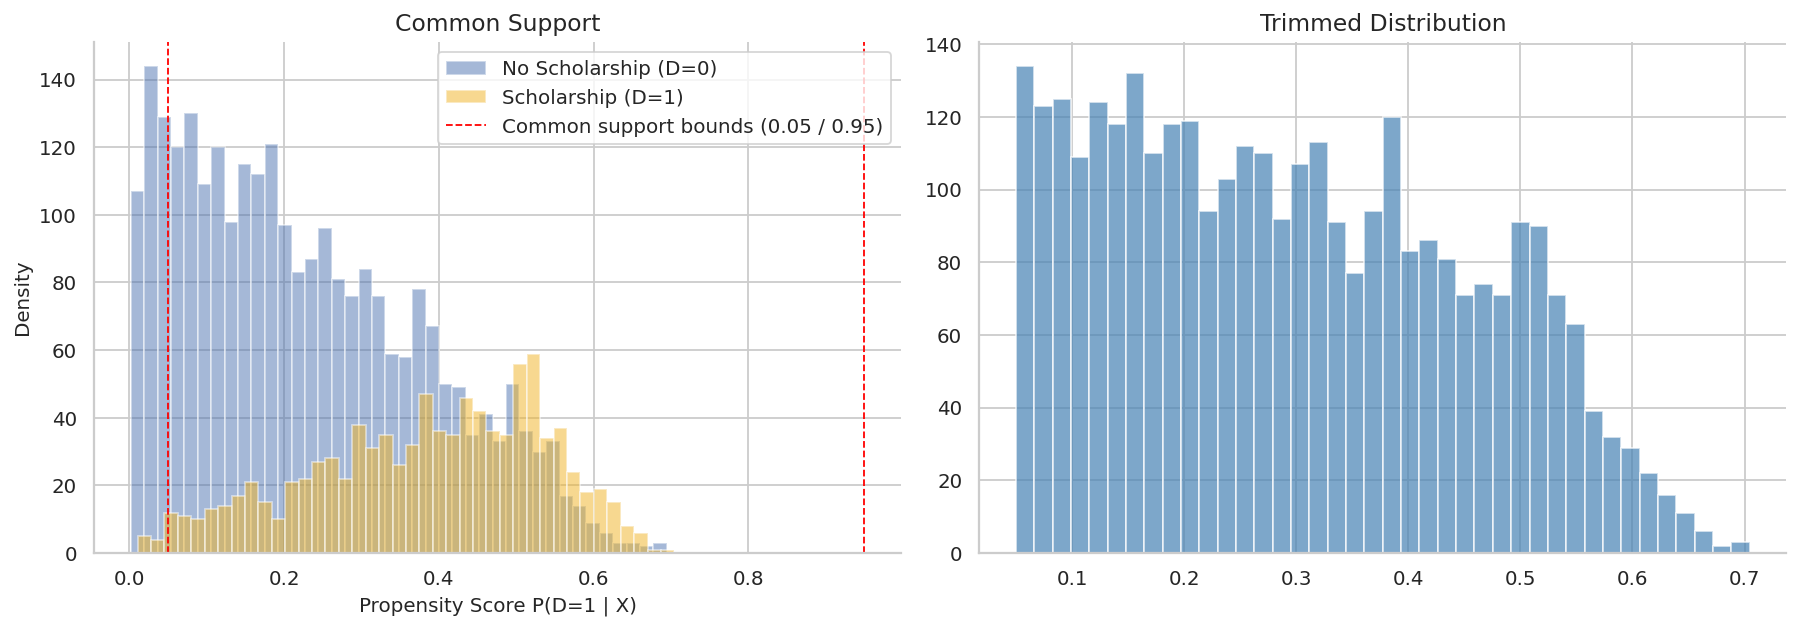

<Figure size 832x624 with 0 Axes>

Observations outside [0.05, 0.95] support: 10.0%
  Treated   outside support: 1.3%
  Untreated outside support: 13.2%


In [51]:

ps_model = LogisticRegressionCV(penalty='l1', solver='liblinear', cv=5, random_state=42)
ps_model.fit(X, D)
propensity_scores = ps_model.predict_proba(X)[:, 1]

# Split by treatment group
ps_treated   = propensity_scores[D == 1]
ps_untreated = propensity_scores[D == 0]

# Create the figure and an array of 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histograms
axes[0].hist(ps_untreated, bins=40, alpha=0.5, color='#4C72B0', label='No Scholarship (D=0)')
axes[0].hist(ps_treated,   bins=40, alpha=0.5, color='#F0B323', label='Scholarship (D=1)')
axes[0].axvline(0.05, color='red', linestyle='--', linewidth=1, label='Common support bounds (0.05 / 0.95)')
axes[0].axvline(0.95, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Propensity Score P(D=1 | X)')
axes[0].set_ylabel('Density')
axes[0].set_title('Common Support')
axes[0].legend()

# Only for common support (propensity scores between 0.05 and 0.95)
in_support = (propensity_scores > 0.05) & (propensity_scores < 0.95)
axes[1].hist(propensity_scores[in_support], bins=40, color='steelblue', alpha=0.7)
axes[1].set_title('Trimmed Distribution')

plt.tight_layout()
plt.show()

# --- Plot 2: Trimmed overlap region ---


plt.tight_layout()
plt.show()

# Summary stats
pct_outside = (~in_support).mean() * 100
print(f"Observations outside [0.05, 0.95] support: {pct_outside:.1f}%")
print(f"  Treated   outside support: {(~in_support[D==1]).mean()*100:.1f}%")
print(f"  Untreated outside support: {(~in_support[D==0]).mean()*100:.1f}%")

In [56]:
# Characteristics of observations outside common support: do they systematically differ from those inside support?

balance_table = X.copy().assign(In_Support=in_support).groupby('In_Support')[features_small_pp ].mean().T
balance_table.columns = ['Outside Support', 'Inside Support']
balance_table['Absolute Difference'] = (balance_table['Inside Support'] - balance_table['Outside Support']).abs()
print("--- Balance Table: Inside vs. Outside Common Support ---")
balance_table

--- Balance Table: Inside vs. Outside Common Support ---


,Outside Support,Inside Support,Absolute Difference
Mother's occupation_1,0.065934,0.019290,0.046644
Mother's occupation_10,0.002747,0.000306,0.002441
Mother's occupation_123,0.000000,0.001531,0.001531
Mother's occupation_125,0.000000,0.000306,0.000306
Mother's occupation_132,0.000000,0.000306,0.000306
...,...,...,...
GDP,-0.219606,0.024475,0.244081
Displaced,0.307692,0.575934,0.268242
Educational special needs,0.000000,0.012247,0.012247
Gender,0.730769,0.300980,0.429789


In [ ]:
# Keep only observations in common support for the rest of the analysis
data_preprocessed_df = data_preprocessed_df[in_support].reset_index(drop=True)
data_preprocessed = data_preprocessed[in_support]
y = y[in_support].reset_index(drop=True)

# 3. Double ML Quantile regression

In [63]:
# DoubleMLData backend — Y and D taken from original data (binary, not scaled)
data_dml = dml.DoubleMLData(
    data_preprocessed_df.assign(
        Target=y['Target'].values),
    y_col='Target',
    d_cols='Scholarship holder',
    x_cols=features_full_pp,
)


In [ ]:

# Quantile grid
tau_vec = np.arange(0.1, 0.95, 0.05)
n_folds = 5

# Learners
logistic_l1 = LogisticRegressionCV(
    penalty='l1',
    solver='liblinear',
    cv=5,
    max_iter=1000,
    random_state=42,
)

decision_tree = DecisionTreeClassifier(
    max_depth=5,           
    min_samples_leaf=20,   
    ccp_alpha=0.001,       
    random_state=42,
)

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,           
    min_samples_leaf=20,   
    ccp_alpha=0.001,       
    n_jobs=-1,
    random_state=42,
)

learners = {
    'Logistic L1':   logistic_l1,
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
}

# Store results per learner
results = {}

for learner_name, learner in learners.items():
    print(f"\n{'='*50}")
    print(f"Fitting QTE with: {learner_name}")
    print(f"{'='*50}")

    # Potential quantiles
    PQ_0    = np.full(len(tau_vec), np.nan)
    PQ_1    = np.full(len(tau_vec), np.nan)
    ci_PQ_0 = np.full((len(tau_vec), 2), np.nan)
    ci_PQ_1 = np.full((len(tau_vec), 2), np.nan)

    for idx_tau, tau in enumerate(tau_vec):
        print(f'  Quantile: {tau:.2f}')

        dml_PQ_0 = dml.DoubleMLPQ(
            data_dml,
            ml_g=clone(learner),
            ml_m=clone(learner),
            score='PQ',
            treatment=0,
            quantile=tau,
            n_folds=n_folds,
            normalize_ipw=True,
            trimming_rule='truncate',
            trimming_threshold=0.05,
        )
        dml_PQ_1 = dml.DoubleMLPQ(
            data_dml,
            ml_g=clone(learner),
            ml_m=clone(learner),
            score='PQ',
            treatment=1,
            quantile=tau,
            n_folds=n_folds,
            normalize_ipw=True,
            trimming_rule='truncate',
            trimming_threshold=0.05,
        )

        dml_PQ_0.fit()
        dml_PQ_1.fit()

        PQ_0[idx_tau]    = dml_PQ_0.coef[0]
        PQ_1[idx_tau]    = dml_PQ_1.coef[0]
        ci_PQ_0[idx_tau] = dml_PQ_0.confint(level=0.95).to_numpy()
        ci_PQ_1[idx_tau] = dml_PQ_1.confint(level=0.95).to_numpy()

    # QTE with uniform CI
    n_cores    = multiprocessing.cpu_count()
    cores_used = np.min([5, n_cores - 1])

    np.random.seed(42)
    dml_QTE = dml.DoubleMLQTE(
        data_dml,
        ml_g=clone(learner),
        ml_m=clone(learner),
        quantiles=tau_vec,
        score='PQ',
        n_folds=n_folds,
        normalize_ipw=True,
        trimming_rule='truncate',
        trimming_threshold=0.05,
    )
    dml_QTE.fit(n_jobs_models=cores_used)
    dml_QTE.bootstrap(n_rep_boot=2000)
    ci_QTE = dml_QTE.confint(level=0.95, joint=True)

    results[learner_name] = {
        'df_pq': pd.DataFrame({
            'Quantile':       tau_vec,
            'DML Y(0)':       PQ_0,
            'DML Y(1)':       PQ_1,
            'DML Y(0) lower': ci_PQ_0[:, 0], 'DML Y(0) upper': ci_PQ_0[:, 1],
            'DML Y(1) lower': ci_PQ_1[:, 0], 'DML Y(1) upper': ci_PQ_1[:, 1],
        }),
        'df_qte': pd.DataFrame({
            'Quantile':      tau_vec,
            'DML QTE':       dml_QTE.coef,
            'DML QTE lower': ci_QTE['2.5 %'],
            'DML QTE upper': ci_QTE['97.5 %'],
        }),
    }

# Plot — one row per learner, 3 columns (PQ0, PQ1, QTE)
colors = {'Logistic L1': '#4C72B0', 'Decision Tree': '#55A868', 'Random Forest': '#C44E52'}

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row, (learner_name, res) in enumerate(results.items()):
    df_pq  = res['df_pq']
    df_qte = res['df_qte']
    color  = colors[learner_name]

    # PQ(0)
    axes[row, 0].plot(df_pq['Quantile'], df_pq['DML Y(0)'], color=color)
    axes[row, 0].fill_between(df_pq['Quantile'], df_pq['DML Y(0) lower'], df_pq['DML Y(0) upper'], alpha=0.3, color=color)
    axes[row, 0].set_title(f'{learner_name} — Y(0) No Scholarship')
    axes[row, 0].set_xlabel('Quantile')
    axes[row, 0].set_ylabel('P(Dropout)')

    # PQ(1)
    axes[row, 1].plot(df_pq['Quantile'], df_pq['DML Y(1)'], color=color)
    axes[row, 1].fill_between(df_pq['Quantile'], df_pq['DML Y(1) lower'], df_pq['DML Y(1) upper'], alpha=0.3, color=color)
    axes[row, 1].set_title(f'{learner_name} — Y(1) Scholarship')
    axes[row, 1].set_xlabel('Quantile')
    axes[row, 1].set_ylabel('P(Dropout)')

    # QTE
    axes[row, 2].plot(df_qte['Quantile'], df_qte['DML QTE'], color=color)
    axes[row, 2].fill_between(df_qte['Quantile'], df_qte['DML QTE lower'], df_qte['DML QTE upper'], alpha=0.3, color=color)
    axes[row, 2].axhline(0, color='red', linestyle='--', linewidth=1, label='Zero effect')
    axes[row, 2].set_title(f'{learner_name} — QTE')
    axes[row, 2].set_xlabel('Quantile')
    axes[row, 2].set_ylabel('QTE')
    axes[row, 2].legend(fontsize=8)

plt.suptitle('Quantile Treatment Effect — Scholarship on Dropout', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Fitting QTE with: Logistic L1
  Quantile: 0.10
